# Dataset background

The project uses the **NLTK Names Corpus**, which includes about 7,900 English first names collected from public sources such as U.S. and U.K. name lists. Each entry has a name and its corresponding gender label, either male or female. The dataset is often used in NLP projects because names contain useful patterns like how they end, their length, or how many vowels they have that can help a model learn to predict whether a name is male or female.

# Project scope & plan

1. **Data split**: Randomly shuffle and partition the corpus into **500 test**, **500 dev-test**, and **~6,900 training** names.
2. **Baseline model**: Start with the textbook name–gender classifier (e.g., Naive Bayes with last-letter features).
3. **Incremental improvements**: Engineer additional features (first/last letters, 2–3 letter suffixes/prefixes, length, vowel/consonant counts, rare-letter flags, etc.) and/or try alternative classifiers from Chapter 6 (Decision Tree, MaxEnt).
4. **Model selection on dev-test**: Iterate using the **dev-test** set to compare variants and tune features/hyperparameters.
5. **Final evaluation on test**: Lock the best model and report performance on the **held-out test set** (accuracy plus confusion matrix, precision, recall, F1; optionally AUC-ROC and log loss).
6. **Comparison**: Briefly compare test vs. dev-test results and explain any gap (expected slight drop on test due to tuning on dev-test).


In [ ]:
import random 
import nltk
from nltk.corpus import names 
from nltk import ConfusionMatrix
from sklearn.metrics import(precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, log_loss, classification_report, confusion_matrix)
import matplotlib.pyplot as plt

## Data Split
I created a labeled dataset using the NLTK Names Corpus, which contains about 7,900 English first names labeled as either male or female. I combined both name lists into a single list of tuples in the format (name, gender) and used the random.shuffle function to randomize the order of the names. Then, I split the data into three parts: 6,900 names for training, 500 names for development testing, and 500 names for final testing. After preparing the data, I defined a function called gender_features to extract useful features from each name, such as the first and last letters, the last two and three letter suffixes, the name length, and the number of vowels. These features were selected because they often reflect gender-related naming patterns, which help the model learn to predict whether a given name is male or female.


In [47]:
# Create labeled list of (name, gender) tuples
labeled_names = ([(name, 'male') for name in names.words('male.txt')] +
                 [(name, 'female') for name in names.words('female.txt')])




In [48]:
random.shuffle(labeled_names)

# Split into train/dev-test/test sets
train_names = labeled_names[1000:]
devtest_names = labeled_names[500:1000]
test_names = labeled_names[:500]


In [49]:
# start with feature names 
def gender_features(word):
    return {
        'last_letter': word[-1].lower(),
        'first_letter': word[0].lower(),
        'suffix2': word[-2:].lower(),
        'suffix3': word[-3:].lower(),
        'length': len(word),
        'vowel_count': sum(1 for c in word.lower() if c in 'aeiou')
    }



In this part of the project, what I did was transform the raw name data into something the model can actually learn from. Using the gender_features function, I extracted patterns from each name like the first and last letters, the last few letter endings, how long the name is, and how many vowels it has. Then, I applied this function to all three datasets: the training set, the development test set, and the final test set. Each name now becomes a set of features paired with its gender label, which helps the model understand what characteristics tend to appear in male versus female names. This step basically prepares the data so the classifier can start learning and making accurate predictions.

In [46]:
train_set = [(gender_features(n), g) for (n, g) in train_names]
devtest_set = [(gender_features(n), g) for (n, g) in devtest_names]
test_set = [(gender_features(n), g) for (n, g) in test_names]


The model performed well, achieving an accuracy of about 80.6% on the development test set and 82.6% on the final test set. These results show that the Naive Bayes classifier was able to learn meaningful patterns from the name features and generalize effectively to unseen data. The small difference between the two scores suggests that the model is not overfitting and is performing consistently, which indicates that it’s a reliable and well-balanced classifier for predicting gender based on names.

In [51]:
cl_model = nltk.NaiveBayesClassifier.train(train_set)

print(f'Dev test Accuracy {nltk.classify.accuracy(cl_model, devtest_set)}')

print(f'Test test Accuracy {nltk.classify.accuracy(cl_model, test_set)}')

Dev test Accuracy 0.806
Test test Accuracy 0.826


In this part of the project, I evaluated the performance of the Naive Bayes classifier using a confusion matrix and probability-based metrics. The confusion matrix compares the model’s predictions with the actual gender labels in the test set. From the results, the classifier correctly identified 263 female names and 158 male names, with some misclassifications (51 females predicted as males and 36 males predicted as females). This shows that the model performs better at recognizing female names but still maintains a strong balance overall. Afterward, I extracted the model’s predicted probabilities for each name being female to use in calculating additional metrics such as precision, recall, F1-score, and AUC-ROC. These steps help assess not only how accurate the model is but also how confidently and consistently it distinguishes between male and female names.


In [ ]:

test_truth = [gender for (features, gender) in test_set]
test_pred = [cl_model.classify(features) for (features, gender) in test_set]

In [54]:
cm =ConfusionMatrix(test_truth, test_pred)
print(cm)

       |   f     |
       |   e     |
       |   m   m |
       |   a   a |
       |   l   l |
       |   e   e |
-------+---------+
female |<263> 51 |
  male |  36<150>|
-------+---------+
(row = reference; col = test)



In [60]:
test_prob = [cl_model.prob_classify(features).prob('female') for (features, gender) in test_set]

y_true = [1 if g == 'female' else 0 for g in test_truth]
y_pred = [1 if g == 'female' else 0 for g in test_pred]
y_prob = test_prob

The evaluation results show that the Naive Bayes gender classifier performed very well overall. The model achieved a precision of 0.88, meaning that when it predicted a name as female, it was correct 88% of the time. Its recall (sensitivity) of 0.838 indicates that it correctly identified about 84% of all actual female names. The F1 score of 0.858 shows a strong balance between precision and recall, while an AUC-ROC of 0.913 demonstrates excellent ability to distinguish between male and female names. The log loss of 0.444 suggests that the model’s predicted probabilities are fairly confident and accurate.

Looking at the classification report, the model performs slightly better for female names (F1 = 0.86) than for male names (F1 = 0.78), which is consistent with the confusion matrix results—263 female names were classified correctly compared to 150 male names. The overall accuracy of 83% confirms that the model generalizes well, showing reliable and balanced performance across both classes.

In [61]:
# 3️⃣ Compute metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
loss = log_loss(y_true, y_prob)

# 4️⃣ Print results
print("Precision:", round(precision, 3))
print("Recall (Sensitivity):", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("AUC-ROC:", round(roc_auc, 3))
print("Log Loss:", round(loss, 3))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['male', 'female']))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Precision: 0.88
Recall (Sensitivity): 0.838
F1 Score: 0.858
AUC-ROC: 0.913
Log Loss: 0.444

Classification Report:
               precision    recall  f1-score   support

        male       0.75      0.81      0.78       186
      female       0.88      0.84      0.86       314

    accuracy                           0.83       500
   macro avg       0.81      0.82      0.82       500
weighted avg       0.83      0.83      0.83       500


Confusion Matrix:
 [[150  36]
 [ 51 263]]


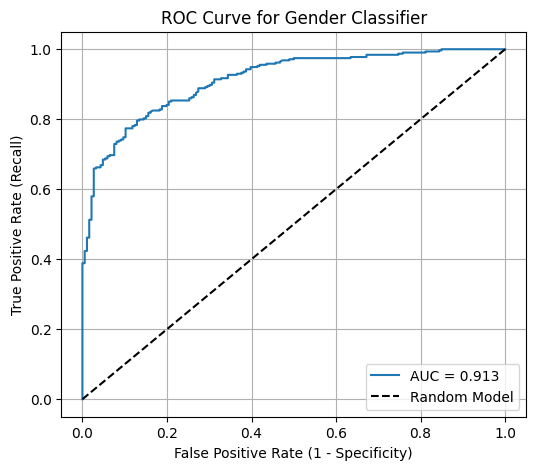

In [62]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--', label='Random Model')
plt.title("ROC Curve for Gender Classifier")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


The ROC curve shown here provides a clear visualization of the model’s ability to distinguish between male and female names. The curve rises sharply toward the top-left corner, indicating a high true positive rate with a low false positive rate. The **AUC (Area Under the Curve) score of 0.913** confirms that the model performs exceptionally well in separating the two classes. A perfect classifier would have an AUC of 1.0, while a random model would fall along the diagonal dashed line. Since this curve is well above the random baseline, it demonstrates that the Naive Bayes classifier is highly effective at correctly identifying genders based on name features and makes confident, accurate predictions across different probability thresholds.


In [ ]:
names_to_check = ["Warner","Emma", "Michael", "Sophia", "Alexis", "Taylor"]
for name in names_to_check:
    prediction= cl_model.classify(gender_features(name))
    [print(f'{name}: {prediction}')]

Warner: male
Emma: female
Michael: male
Sophia: female
Alexis: male
Taylor: male
